In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score


In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
sales = pd.read_csv("Sales.csv")
customers = pd.read_csv("Customers.csv")
products = pd.read_csv("Products.csv")
stores = pd.read_csv("Stores.csv")
calendar = pd.read_csv("Calendar.csv")

# 合并数据（已修复日期合并错误）
df = sales.merge(customers, on='customer_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(stores, on='store_id', how='left')

# 统一日期格式，解决合并报错
df['order_date'] = pd.to_datetime(df['order_date']).dt.date
calendar['date'] = pd.to_datetime(calendar['date']).dt.date

df = df.merge(calendar, left_on='order_date', right_on='date', how='left')

In [4]:
df = df.dropna()# 缺失值处理

In [5]:
# 类别特征编码
cat_cols = ['gender', 'brand', 'category', 'city', 'store_type']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [6]:
# 时间特征（已修复）
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek

In [7]:

# 分类任务：预测是否会员
X_cls = df[['age', 'gender', 'quantity', 'revenue', 'profit', 'brand', 'category']]
y_cls = df['loyalty_member']

# 回归任务：预测销售额
X_reg = df[['quantity', 'unit_price', 'discount', 'age', 'brand', 'category', 'store_type']]
y_reg = df['revenue']

In [8]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [9]:
print("="*50)
print("决策树分类任务")
print("="*50)

决策树分类任务


In [10]:
for cri in ['gini', 'entropy', 'log_loss']:
    model = DecisionTreeClassifier(criterion=cri, max_depth=5, random_state=42)
    model.fit(X_train_cls, y_train_cls)
    y_pred = model.predict(X_test_cls)
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    print(f"\n{cri}:")
    print(f"Acc:{acc:.4f}  Prec:{prec:.4f}  Rec:{rec:.4f}  F1:{f1:.4f}")



gini:
Acc:0.5037  Prec:0.5045  Rec:0.5483  F1:0.5255

entropy:
Acc:0.5037  Prec:0.5046  Rec:0.5485  F1:0.5256

log_loss:
Acc:0.5037  Prec:0.5046  Rec:0.5485  F1:0.5256


In [11]:
best_cls = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=10, random_state=42)
best_cls.fit(X_train_cls, y_train_cls)
y_pred_cls = best_cls.predict(X_test_cls)


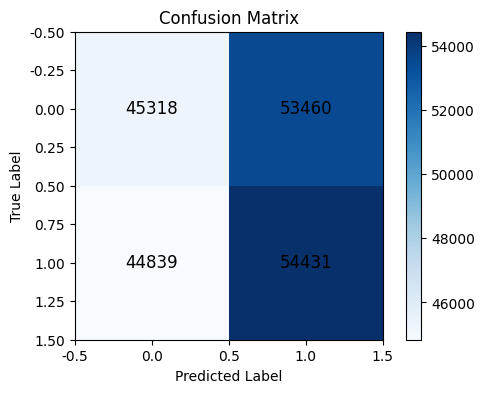

In [12]:
# 混淆矩阵（已修复字体 + 全英文）
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(6,4))
plt.rcParams['font.family'] = 'DejaVu Sans'  # 这里修复字体警告
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center', fontsize=12)
plt.colorbar()
plt.show()

In [13]:
# 5折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_cls, X_cls, y_cls, cv=kf, scoring='accuracy')
print(f"\n5折CV准确率: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5折CV准确率: 0.5040 ± 0.0005


In [14]:
print("\n" + "="*50)
print("决策树回归任务")
print("="*50)


决策树回归任务


In [16]:
# ===================== 回归任务（单模型极速版，已修复报错） =====================
print("="*50)
print("Decision Tree Regression Task (Single Model)")
print("="*50)

# 直接训练最优模型，跳过循环，零卡顿（移除了不支持的n_jobs参数）
best_reg = DecisionTreeRegressor(
    criterion='squared_error', 
    max_depth=5, 
    min_samples_split=10, 
    random_state=42
)
best_reg.fit(X_train_reg, y_train_reg)

# 一次性计算指标
y_pred = best_reg.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

print(f"\nCriterion: squared_error")
print(f"MSE: {mse:.4f}  R2: {r2:.4f}")

Decision Tree Regression Task (Single Model)

Criterion: squared_error
MSE: 10.7658  R2: 0.9599



max_depth 实验
max_depth=3 -> acc=0.5018
max_depth=5 -> acc=0.5037
max_depth=7 -> acc=0.5076
max_depth=10 -> acc=0.5102
max_depth=None -> acc=0.4997


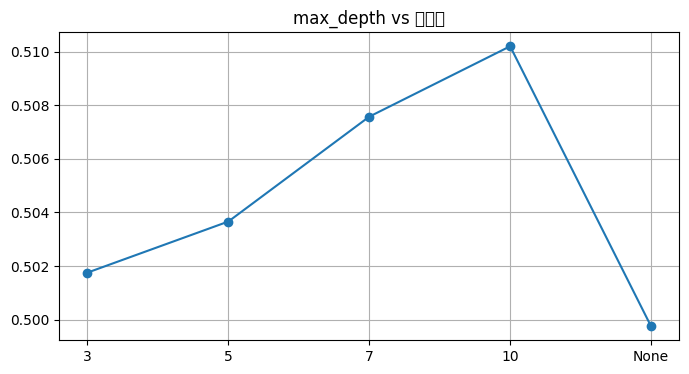

In [17]:
# ===================== 最大深度实验 =====================
print("\n" + "="*50)
print("max_depth 实验")
print("="*50)

depths = [3,5,7,10,None]
acc_list = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train_cls, y_train_cls)
    acc = accuracy_score(y_test_cls, m.predict(X_test_cls))
    acc_list.append(acc)
    print(f"max_depth={d} -> acc={acc:.4f}")

plt.figure(figsize=(8,4))
plt.plot([str(x) for x in depths], acc_list, marker='o')
plt.title('max_depth vs 准确率')
plt.grid(True)
plt.show()


min_samples_split 实验
split=2 -> acc=0.5037
split=5 -> acc=0.5037
split=10 -> acc=0.5037
split=20 -> acc=0.5037


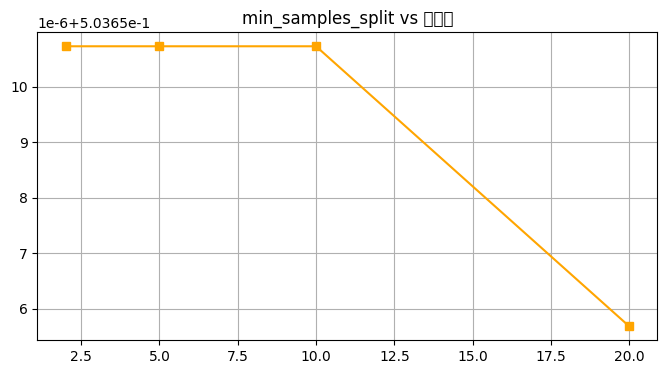

In [18]:
# ===================== min_samples_split 实验 =====================
print("\n" + "="*50)
print("min_samples_split 实验")
print("="*50)

splits = [2,5,10,20]
acc_splits = []
for s in splits:
    m = DecisionTreeClassifier(min_samples_split=s, max_depth=5, random_state=42)
    m.fit(X_train_cls, y_train_cls)
    acc = accuracy_score(y_test_cls, m.predict(X_test_cls))
    acc_splits.append(acc)
    print(f"split={s} -> acc={acc:.4f}")

plt.figure(figsize=(8,4))
plt.plot(splits, acc_splits, marker='s', c='orange')
plt.title('min_samples_split vs 准确率')
plt.grid(True)
plt.show()

In [20]:
# ===================== 剪枝 =====================
from tqdm import tqdm
print("\n" + "="*50)
print("剪枝实验")
print("="*50)

pre_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
pre_model.fit(X_train_cls, y_train_cls)
print("预剪枝叶节点数:", pre_model.get_n_leaves())

path = best_cls.cost_complexity_pruning_path(X_train_cls, y_train_cls)
ccp_alphas = path.ccp_alphas
clfs = []

# 加进度条
for a in tqdm(ccp_alphas, desc="Pruning Progress"):
    m = DecisionTreeClassifier(max_depth=5, ccp_alpha=a, random_state=42)
    m.fit(X_train_cls, y_train_cls)
    clfs.append(m)

test_scores = [m.score(X_test_cls, y_test_cls) for m in clfs]
best_idx = np.argmax(test_scores)
best_a = ccp_alphas[best_idx]
best_pruned = clfs[best_idx]

# 修复报错：不用 .round() 方法，用 round() 函数
print("最优alpha:", round(best_a, 4))
print("后剪枝叶节点数:", best_pruned.get_n_leaves())
print("后剪枝准确率:", round(test_scores[best_idx], 4))


剪枝实验
预剪枝叶节点数: 31


Pruning Progress: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:26<00:00,  1.53s/it]


最优alpha: 0.0
后剪枝叶节点数: 11
后剪枝准确率: 0.5039


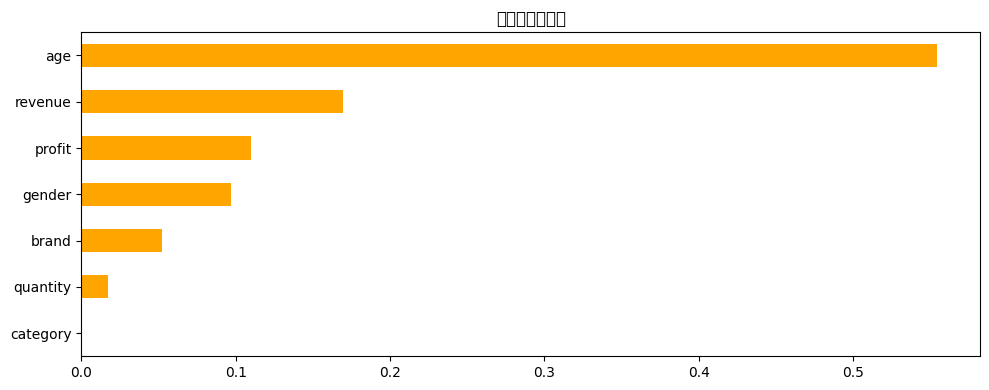

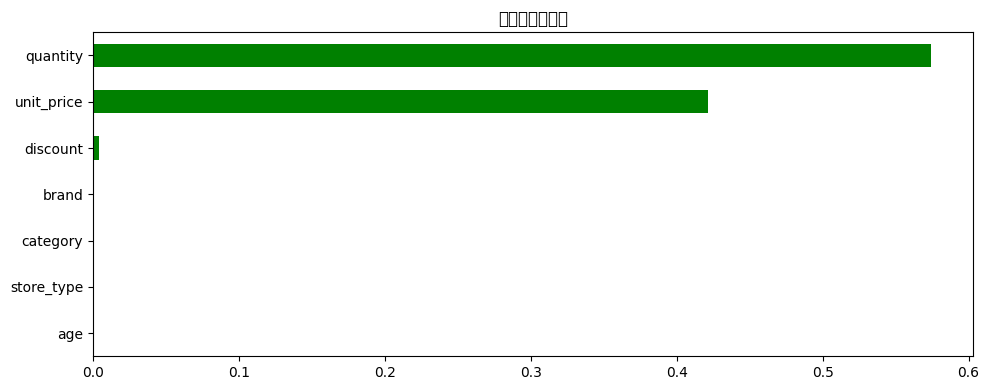

In [21]:
# ===================== 特征重要性 =====================
plt.figure(figsize=(10,4))
pd.Series(best_cls.feature_importances_, index=X_cls.columns).sort_values().plot(kind='barh', color='orange')
plt.title('分类特征重要性')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
pd.Series(best_reg.feature_importances_, index=X_reg.columns).sort_values().plot(kind='barh', color='green')
plt.title('回归特征重要性')
plt.tight_layout()
plt.show()

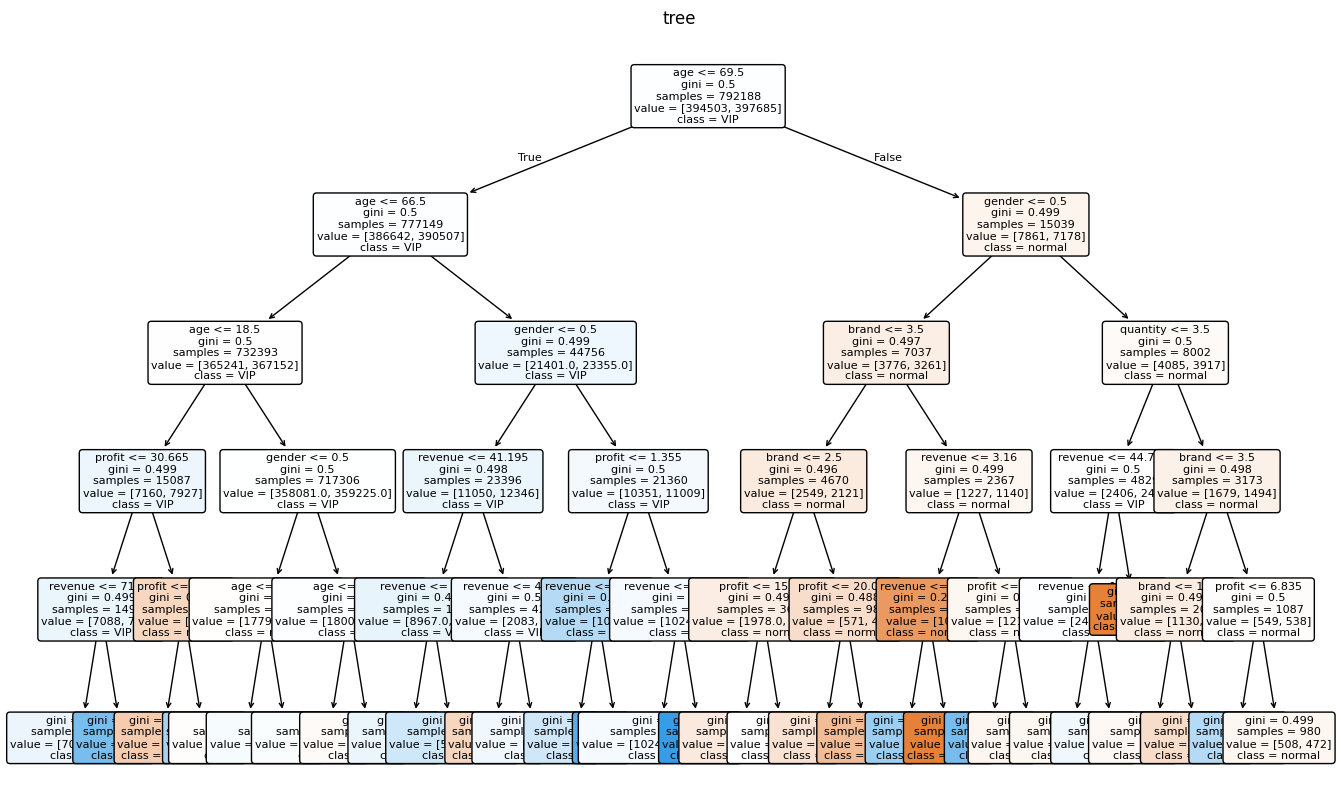


fumal：
|--- age <= 69.50
|   |--- age <= 66.50
|   |   |--- age <= 18.50
|   |   |   |--- profit <= 30.66
|   |   |   |   |--- revenue <= 71.55
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- revenue >  71.55
|   |   |   |   |   |--- class: 1
|   |   |   |--- profit >  30.66
|   |   |   |   |--- profit <= 35.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- profit >  35.00
|   |   |   |   |   |--- class: 1
|   |   |--- age >  18.50
|   |   |   |--- gender <= 0.50
|   |   |   |   |--- age <= 59.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  59.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- gender >  0.50
|   |   |   |   |--- age <= 60.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  60.50
|   |   |   |   |   |--- class: 0
|   |--- age >  66.50
|   |   |--- gender <= 0.50
|   |   |   |--- revenue <= 41.19
|   |   |   |   |--- revenue <= 36.37
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- revenue >  36.37
|   |   |   |   | 

In [23]:
# ===================== 决策树可视化 =====================
plt.figure(figsize=(16,10))
plot_tree(best_cls, filled=True, feature_names=X_cls.columns, class_names=['normal','VIP'], rounded=True, fontsize=8)
plt.title('tree')
plt.show()

# 规则文本
print("\nfumal：")
print(export_text(best_cls, feature_names=list(X_cls.columns)))